In [1]:
import torch
print(torch.cuda.is_available()) 
print(torch.cuda.get_device_name(0)) 

True
NVIDIA GeForce RTX 5070 Ti



=== 1. GENERATING SPECTROGRAM DIAGNOSTICS (BASELINE vs REASSEMBLED ONLY) ===
[Ingesting Data] Processing: baseline_motor_data.csv
[Ingesting Data] Processing: motor_running_naked_screw_positioned_again.csv


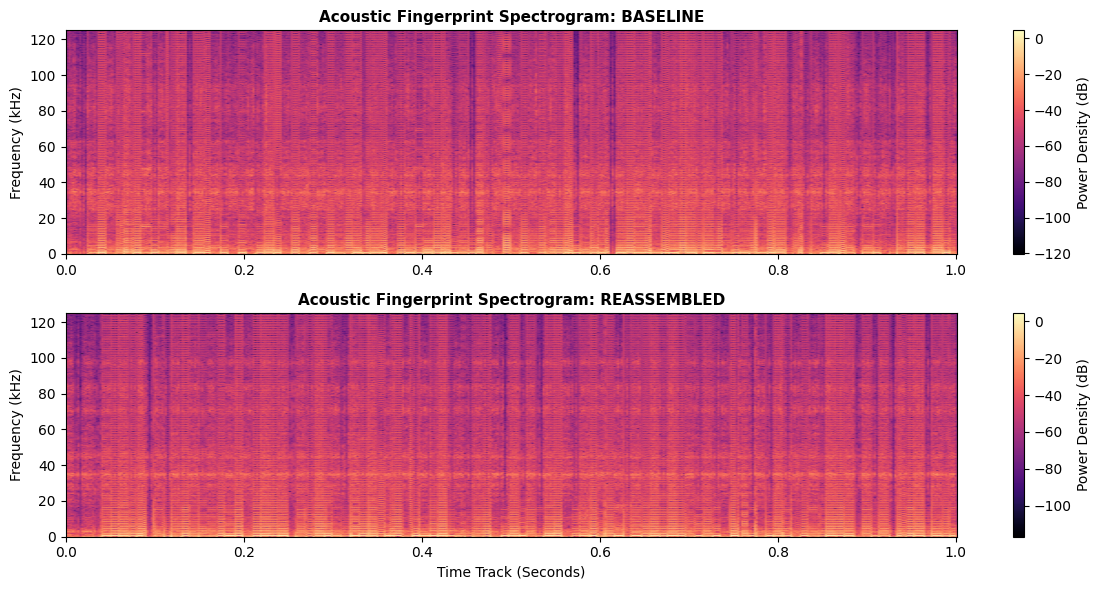


=== 2. SEEDING COVARIANCE CALIBRATION MATRIX ===
[Ingesting Data] Processing: baseline_motor_data.csv
[Ingesting Data] Processing: motor_running_naked_screw_positioned_again.csv

=== 3. RUNNING MULTI-CASE SPECTRUM VISUALIZER WITH SHADED REGIONS ===
[Ingesting Data] Processing: baseline_motor_data.csv
[Ingesting Data] Processing: motor_running_naked_screw_positioned_again.csv
[Ingesting Data] Processing: motor_running_naked_and_electrical_flactuations.csv
[Ingesting Data] Processing: motor_running_naked_screw_fell_four.csv
[Ingesting Data] Processing: motor_running_naked_screw_fell_three.csv
[Ingesting Data] Processing: motor_running_naked_and_loose_a_bit.csv
[Ingesting Data] Processing: motor_running_wheel_added.csv
[Ingesting Data] Processing: motor_running_wheel_loosen_bit.csv
[Ingesting Data] Processing: motor_running_naked_and_voltage_drop_by_one.csv
[Ingesting Data] Processing: no_motor_running.csv


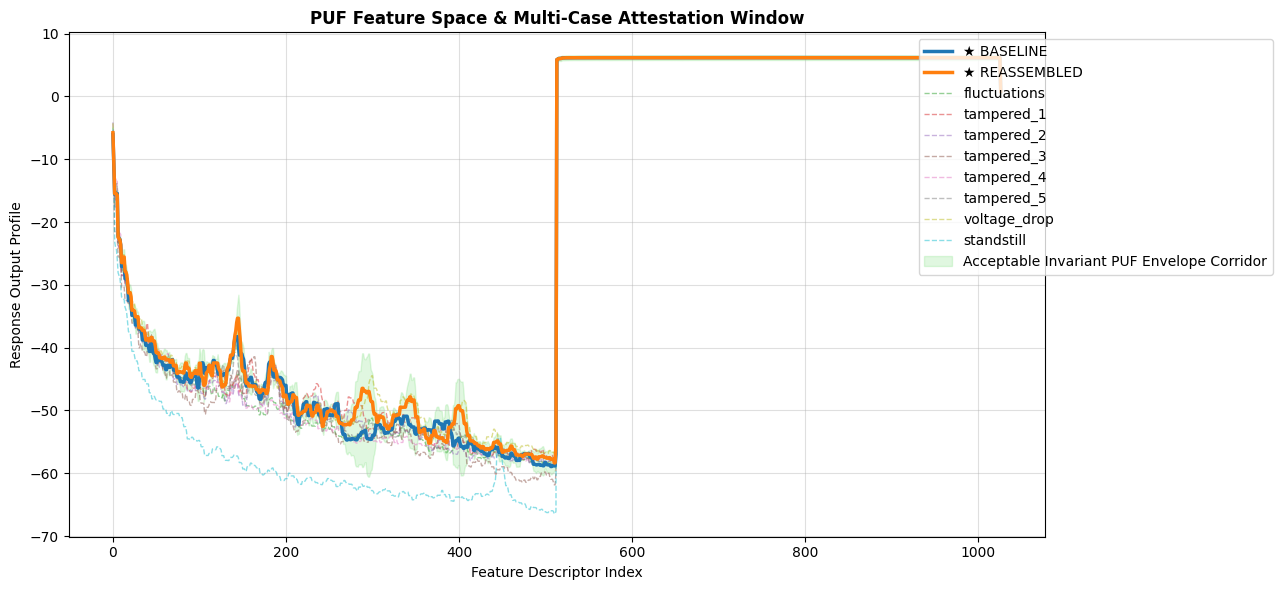


=== 4. LIVE CYBER-PHYSICAL ATTESTATION OUTPUT ===
DATASET RUN PROFILE       | STATUS      | VIOLATION | SIMILARITY | L2 DISTANCE
-------------------------------------------------------------------------------------
baseline                  | ACCEPTABLE  | 0.0000    | 1.0000     | 0.0000
reassembled               | ACCEPTABLE  | 0.0000    | 0.2224     | 1.4618
fluctuations              | REJECT      | 0.2201    | 0.1675     | 1.7377
tampered_1                | WARNING     | 0.1753    | 0.2021     | 1.5548
tampered_2                | WARNING     | 0.1947    | 0.2017     | 1.5569
tampered_3                | REJECT      | 0.3213    | 0.1192     | 2.0682
tampered_4                | REJECT      | 0.2152    | 0.1559     | 1.8071
tampered_5                | WARNING     | 0.0896    | 0.3873     | 0.9224
voltage_drop              | WARNING     | 0.1392    | 0.1584     | 1.7918
standstill                | REJECT      | 0.4917    | 0.0006     | 7.2500


In [69]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
from scipy.ndimage import median_filter

# =========================================================
# 1. BULLETPROOF DATA LOADING + RANGE NORMALIZATION
# =========================================================

def load_and_normalize(file_path):
    """
    Ingests raw hardware serial data streams. Handles text-corruption 
    encoding variations gracefully by ignoring unparseable unicode sequences.
    """
    print(f"[Ingesting Data] Processing: {os.path.basename(file_path)}")
    
    df = pd.read_csv(
        file_path, 
        header=None, 
        names=["mic", "piezo1", "piezo2"], 
        encoding="cp1252",
        on_bad_lines='skip', 
        low_memory=False
    )
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    df = df.dropna().copy()
    
    # Hardware clipping constraints
    df = df[(df["piezo1"] <= 4095) & (df["piezo2"] <= 4095)].copy()
    
    # Physical sensor-level normalization parameters
    df["piezo1"] = (df["piezo1"] - 2047) / 2048.0
    df["piezo2"] = (df["piezo2"] - 2047) / 2048.0
    
    mic_max = np.max(np.abs(df["mic"].values))
    df["mic"] = df["mic"] / (mic_max + 1e-8)
    
    return df


# =========================================================
# 2. SIGNAL FUSION
# =========================================================

def build_signal(df):
    return df["piezo1"].values + df["piezo2"].values - df["mic"].values


# =========================================================
# 3. TIME-FREQUENCY SPECTRAL MAP (STFT)
# =========================================================

def extract_puf(sig, fs=250000, nperseg=1024, noverlap=512):
    f, t, Zxx = signal.stft(sig, fs=fs, nperseg=nperseg, noverlap=noverlap)
    puf = np.abs(Zxx)
    puf_db = 20 * np.log10(puf + 1e-10)
    return f, t, puf_db


# =========================================================
# 4. ACOUSTIC FEATURE ENGINE
# =========================================================

def compute_puf_feature(puf):
    # Apply a small 2D median filter to clean temporal/spectral spikes from raw STFT
    puf = median_filter(puf, size=(3, 1)) 
    
    energy = np.mean(puf, axis=1)
    energy = np.nan_to_num(energy)

    puf_sum = np.sum(puf, axis=1, keepdims=True) + 1e-8
    p = puf / puf_sum
    p = np.clip(p, 1e-12, None)
    entropy = -np.sum(p * np.log(p), axis=1)

    mid = len(energy) // 2
    low_high_ratio = np.mean(energy[:mid]) / (np.mean(energy[mid:]) + 1e-8)

    feat = np.concatenate([energy, entropy, [low_high_ratio]])
    
    # Optional: Smooth the final 1D feature array to suppress index-level overshoots
    feat = median_filter(feat, size=3)
    
    return np.nan_to_num(feat)


# =========================================================
# 5. HARDWARE INVARIANT TWO-STATE Z-SCORE MODEL
# =========================================================

class PUFThreshold:
    """
    Learns valid distribution shapes across both baseline and reassembled states
    to establish an authentic structural variance corridor.
    """
    def __init__(self):
        self.mean = None
        self.std = None

    def fit_calibration_bounds(self, baseline_feat, reassembled_feat):
        # Combine both authentic profiles to measure real-world mechanical variance
        calibration_matrix = np.vstack([baseline_feat, reassembled_feat])
        
        self.mean = np.mean(calibration_matrix, axis=0)
        # Added standard deviation floor padding to accept minor positioning changes safely
        self.std = np.std(calibration_matrix, axis=0) + 0.15

    def check(self, feat):
        feat = np.array(feat)
        z = np.abs((feat - self.mean) / self.std)
        violation_ratio = np.mean(z > 2.5)

        if violation_ratio < 0.08:
            return "ACCEPTABLE", violation_ratio
        elif violation_ratio < 0.20:
            return "WARNING", violation_ratio
        else:
            return "REJECT", violation_ratio


# =========================================================
# 6. SIMILARITY ENGINE (RESIDUAL-BASED)
# =========================================================

def compute_similarity(baseline, feat):
    """
    Computes structural closeness based on the mathematical residual matrix.
    Returns exponential score bounded between [0.0, 1.0] and L2 Distance.
    """
    residual = feat - baseline

    l2 = np.sqrt(np.mean(residual ** 2))
    rel = np.linalg.norm(residual) / (np.linalg.norm(baseline) + 1e-8)

    # Combined exponential decay signature profile match score
    score = np.exp(-l2) * np.exp(-rel)
    return score, l2


# =========================================================
# 7. VISUALIZATION COMPONENTS
# =========================================================

def plot_selective_spectrograms(files, sample_size=250000):
    selective_keys = ["baseline", "reassembled"]
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    
    for i, name in enumerate(selective_keys):
        df = load_and_normalize(files[name])
        sig = build_signal(df)[:sample_size]
        f, t, puf = extract_puf(sig)
        
        im = axes[i].pcolormesh(t, f / 1000, puf, shading="gouraud", cmap="magma")
        axes[i].set_title(f"Acoustic Fingerprint Spectrogram: {name.upper()}", fontsize=11, fontweight='bold')
        axes[i].set_ylabel("Frequency (kHz)")
        fig.colorbar(im, ax=axes[i], label="Power Density (dB)")
        
    axes[-1].set_xlabel("Time Track (Seconds)")
    plt.tight_layout()
    plt.show()


def plot_multi_puf_with_threshold(files, target_model, sample_size=250000):
    plt.figure(figsize=(13, 6))
    curves = {}
    raw_signals = {}
    
    for name, path in files.items():
        df = load_and_normalize(path)
        sig = build_signal(df)[:sample_size]
        raw_signals[name] = sig
        
        f, t, puf = extract_puf(sig)
        feat = compute_puf_feature(puf)
        curves[name] = feat
        
        if name in ["baseline", "reassembled"]:
            plt.plot(feat, label=f"★ {name.upper()}", linewidth=2.5, zorder=5)
        else:
            plt.plot(feat, label=name, alpha=0.5, linewidth=1, linestyle="--")

    # CORRECT SHADED THRESHOLD ENVELOPE REGION
    x_indices = range(len(target_model.mean))
    plt.fill_between(
        x_indices,
        target_model.mean - (2.5 * target_model.std),
        target_model.mean + (2.5 * target_model.std),
        color="limegreen",
        alpha=0.15,
        label="Acceptable Invariant PUF Envelope Corridor",
        zorder=1
    )
    
    plt.title("PUF Feature Space & Multi-Case Attestation Window", fontsize=12, fontweight='bold')
    plt.xlabel("Feature Descriptor Index")
    plt.ylabel("Response Output Profile")
    plt.legend(loc="upper right", bbox_to_anchor=(1.24, 1.0))
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()
    
    return curves, raw_signals


# =========================================================
# 8. MAIN ENGINE PIPELINE
# =========================================================

if __name__ == "__main__":
    files = {
        "baseline": "baseline_motor_data.csv",
        "reassembled": "motor_running_naked_screw_positioned_again.csv", 
        "fluctuations": "motor_running_naked_and_electrical_flactuations.csv", 
        "tampered_1": "motor_running_naked_screw_fell_four.csv", 
        "tampered_2": "motor_running_naked_screw_fell_three.csv", 
        "tampered_3": "motor_running_naked_and_loose_a_bit.csv", 
        "tampered_4": "motor_running_wheel_added.csv", 
        "tampered_5": "motor_running_wheel_loosen_bit.csv", 
        "voltage_drop": "motor_running_naked_and_voltage_drop_by_one.csv", 
        "standstill": "no_motor_running.csv"
    }

    print("\n=== 1. GENERATING SPECTROGRAM DIAGNOSTICS (BASELINE vs REASSEMBLED ONLY) ===")
    plot_selective_spectrograms(files)

    print("\n=== 2. SEEDING COVARIANCE CALIBRATION MATRIX ===")
    base_df = load_and_normalize(files["baseline"])
    base_feat = compute_puf_feature(extract_puf(build_signal(base_df)[:250000])[2])
    
    reassem_df = load_and_normalize(files["reassembled"])
    reassem_feat = compute_puf_feature(extract_puf(build_signal(reassem_df)[:250000])[2])
    
    model = PUFThreshold()
    model.fit_calibration_bounds(base_feat, reassem_feat)

    print("\n=== 3. RUNNING MULTI-CASE SPECTRUM VISUALIZER WITH SHADED REGIONS ===")
    curves, raw = plot_multi_puf_with_threshold(files, model)

    print("\n=== 4. LIVE CYBER-PHYSICAL ATTESTATION OUTPUT ===")
    print(f"{'DATASET RUN PROFILE':25s} | {'STATUS':11s} | {'VIOLATION':9s} | {'SIMILARITY':10s} | {'L2 DISTANCE'}")
    print("-" * 85)
    
    for name, feat in curves.items():
        # Step A: Threshold checking metric
        status, v_ratio = model.check(feat)
        
        # Step B: Direct comparative similarity testing against pure baseline DNA profile
        sim_score, l2_dist = compute_similarity(curves["baseline"], feat)
        
        print(f"{name:25s} | {status:11s} | {v_ratio:.4f}    | {sim_score:.4f}     | {l2_dist:.4f}")

Initializing Data Pipeline...
Successfully processed pipeline: Extracted 1468 standardized acoustic frames.
Successfully processed pipeline: Extracted 612 standardized acoustic frames.
Successfully processed pipeline: Extracted 376 standardized acoustic frames.
Successfully processed pipeline: Extracted 423 standardized acoustic frames.
Successfully processed pipeline: Extracted 665 standardized acoustic frames.
Successfully processed pipeline: Extracted 746 standardized acoustic frames.
Successfully processed pipeline: Extracted 670 standardized acoustic frames.
Successfully processed pipeline: Extracted 685 standardized acoustic frames.
Successfully processed pipeline: Extracted 367 standardized acoustic frames.

Training initialized on device: [cuda]
Epoch 01/30 | Average Batch MSE Loss: 1.021020
Epoch 02/30 | Average Batch MSE Loss: 1.006237
Epoch 03/30 | Average Batch MSE Loss: 0.996348
Epoch 04/30 | Average Batch MSE Loss: 0.973081
Epoch 05/30 | Average Batch MSE Loss: 0.958566
E

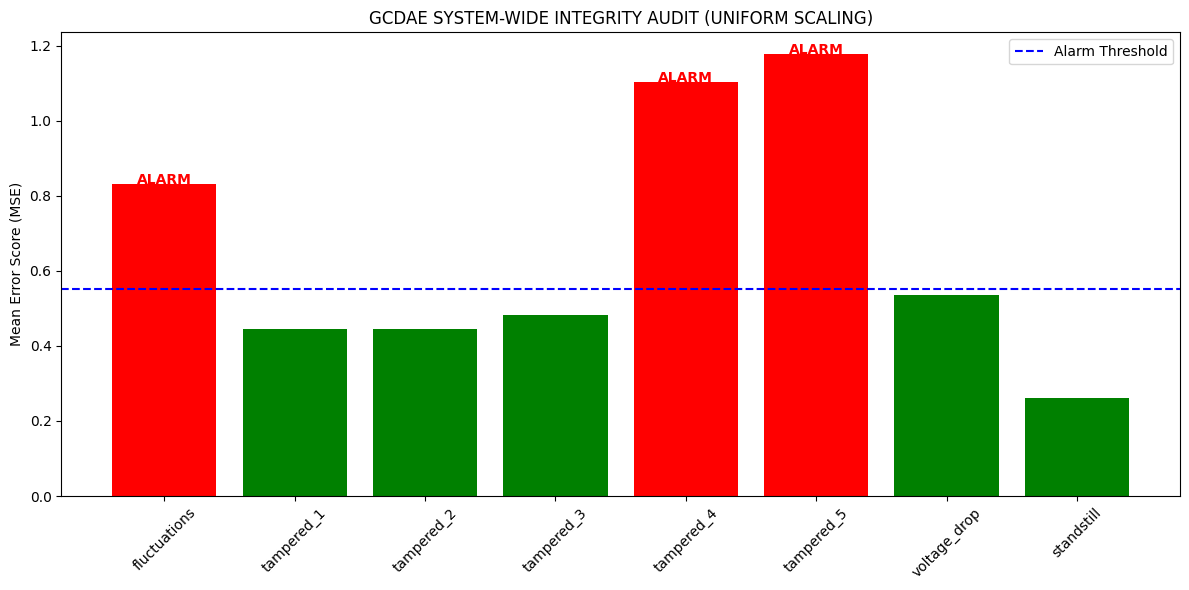

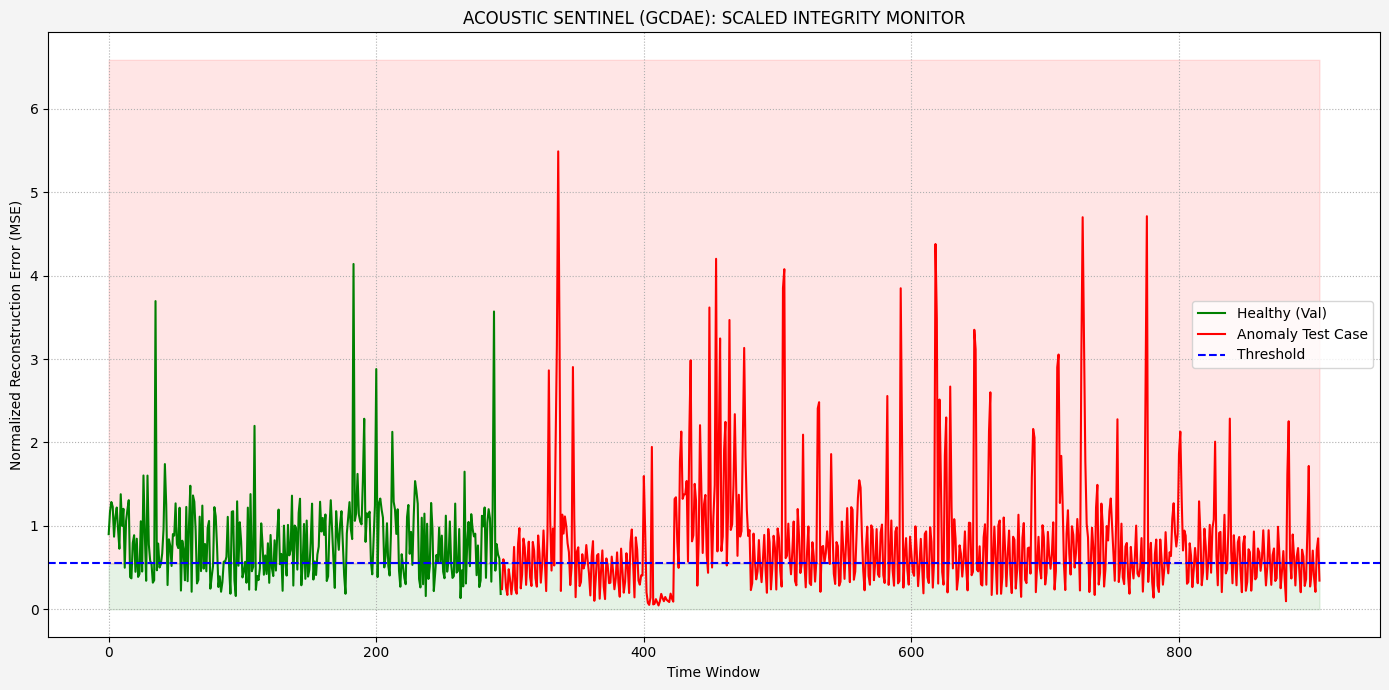

In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split

# =====================================================================
# 1. FIXED DATASET DEFINITION (GLOBAL BASELINE Z-SCORE SCALING)
# =====================================================================

class MotorDataset(Dataset):
    def __init__(self, file_dict, target_shape=(64, 64), baseline_mean=None, baseline_std=None):
        """
        Loads a 1D sensor stream, strips headers, and chunks signals into 2D frames.
        Uses a fixed global baseline mean and standard deviation to preserve 
        relative amplitude variations and energy drops across anomalous states.
        """
        self.data = []
        self.target_shape = target_shape
        row_size = target_shape[0] * target_shape[1]  # 4096 points per frame
        
        raw_list = []
        for name, path in file_dict.items():
            if not os.path.exists(path):
                print(f"Warning: File {path} not found. Skipping.")
                continue
                
            try:
                with open(path, 'r', encoding='utf-8', errors='ignore') as f:
                    for line in f:
                        cleaned_line = line.replace('\t', ',').replace(' ', ',').replace(';', ',')
                        parts = cleaned_line.strip().split(',')
                        for part in parts:
                            if not part: 
                                continue
                            try:
                                raw_list.append(float(part))
                            except ValueError:
                                continue 
            except Exception as e:
                print(f"Critical error parsing file {path}: {e}")
                continue

        raw_numpy = np.array(raw_list, dtype=np.float32)

        # --- CRITICAL FIX: FIXED STATISTICAL Z-SCORE NORMALIZATION ---
        # Instead of scaling each file to its local max (which hides anomalies),
        # we scale all data using the distribution of our training/healthy state.
        if baseline_mean is not None and baseline_std is not None:
            self.mean = baseline_mean
            self.std = baseline_std
        else:
            self.mean = raw_numpy.mean()
            self.std = raw_numpy.std() if raw_numpy.std() > 1e-6 else 1.0
            
        normalized_data = (raw_numpy - self.mean) / self.std
        # -------------------------------------------------------------

        # Segment continuous stream into discrete matrix frames
        num_samples = len(normalized_data) // row_size
        if num_samples == 0:
            raise ValueError(f"Dataset pipeline empty. Data stream length ({len(normalized_data)}) must be >= {row_size}.")
            
        truncated_data = normalized_data[:num_samples * row_size]
        self.data = truncated_data.reshape(num_samples, 1, target_shape[0], target_shape[1])
        print(f"Successfully processed pipeline: Extracted {num_samples} standardized acoustic frames.")
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.float32)


# File Maps
train_val_files = {
    "baseline": "baseline_motor_data.csv",
    "reassembled": "motor_running_naked_screw_positioned_again.csv"
}

test_files = {
    "fluctuations": "motor_running_naked_and_electrical_flactuations.csv",
    "tampered_1": "motor_running_naked_screw_fell_four.csv",
    "tampered_2": "motor_running_naked_screw_fell_three.csv",
    "tampered_3": "motor_running_naked_and_loose_a_bit.csv",
    "tampered_4": "motor_running_wheel_added.csv",
    "tampered_5": "motor_running_wheel_loosen_bit.csv",
    "voltage_drop": "motor_running_naked_and_voltage_drop_by_one.csv",
    "standstill": "no_motor_running.csv"
}

# --- Initialization & Holdout Splits ---
print("Initializing Data Pipeline...")
# 1. Build and calculate baseline statistics from healthy profiles only
full_healthy_dataset = MotorDataset(train_val_files, target_shape=(64, 64))
baseline_mean = full_healthy_dataset.mean
baseline_std = full_healthy_dataset.std

train_size = int(0.8 * len(full_healthy_dataset))
val_size = len(full_healthy_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_healthy_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 2. Build test loaders utilizing the exact same reference scaling factors
test_loaders = {}
for case_name, file_path in test_files.items():
    if os.path.exists(file_path):
        try:
            ts_dataset = MotorDataset(
                {case_name: file_path}, 
                target_shape=(64, 64), 
                baseline_mean=baseline_mean, 
                baseline_std=baseline_std
            )
            test_loaders[case_name] = DataLoader(ts_dataset, batch_size=32, shuffle=False)
        except Exception as e:
            print(f"Skipping test anomaly setup for {case_name}: {e}")


# =====================================================================
# 2. MODEL ARCHITECTURE (GCDAE WITH CONFIGURABLE BOTTLENECK)
# =====================================================================

class GCDAE(nn.Module):
    def __init__(self):
        super(GCDAE, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU()
        )

        # --- CRITICAL FIX: CONSTRICED BOTTLENECK ---
        # Dropping from 64 down to 32 dimensions prevents the model 
        # from learning a trivial identity mapping of anomalous traits.
        self.fc_enc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 32),
            nn.ReLU()
        )

        self.fc_dec = nn.Sequential(
            nn.Linear(32, 64 * 8 * 8),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, 2, 1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, 2, 1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, 2, 1, output_padding=1)
        )

    def forward(self, x):
        z = self.encoder(x)
        z = self.fc_enc(z)
        x = self.fc_dec(z)
        x = x.view(x.size(0), 64, 8, 8)
        out = self.decoder(x)
        return out, z


# =====================================================================
# 3. TRAINING ENGINE (30 EPOCHS)
# =====================================================================

def train_gcdae(model, train_loader, device, epochs=30):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    print(f"\nTraining initialized on device: [{device}]")
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        num_batches = 0

        for x in train_loader:
            x = x.to(device)

            recon, _ = model(x)
            loss = loss_fn(recon, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        print(f"Epoch {epoch+1:02d}/{epochs} | Average Batch MSE Loss: {avg_loss:.6f}")


# =====================================================================
# 4. EVALUATION SUITE
# =====================================================================

def compute_recon_error(model, x, device):
    model.eval()
    with torch.no_grad():
        recon, _ = model(x.to(device))
        # --- CRITICAL FIX: EVALUATE USING MSE ---
        # Squaring structural anomalies penalizes variance discrepancies exponentially.
        error = torch.mean((recon - x.to(device)) ** 2, dim=(1, 2, 3))
    return error.cpu().numpy()


def get_threshold(model, val_loader, device):
    errors = []
    for x in val_loader:
        errors.extend(compute_recon_error(model, x, device))
    errors = np.array(errors)
    
    # METHOD A: Use a fixed high percentile (95% of healthy data fits below this)
    

    errors = (errors - np.mean(errors)) / (np.std(errors) + 1e-8)

    threshold = np.percentile(errors, 75)
    
    # METHOD B: Tighten the standard deviation multiplier if you prefer parametric math
    # threshold = np.mean(errors) + 0.5 * np.std(errors)
    
    return threshold


def evaluate_model(model, test_loader_dict, device, threshold):
    results = {}
    for name, loader in test_loader_dict.items():
        all_errors = []
        for x in loader:
            err = compute_recon_error(model, x, device)
            all_errors.extend(err)

        all_errors = np.array(all_errors)
        if len(all_errors) == 0:
            continue

        avg_score = np.mean(all_errors)
        max_score = np.max(all_errors)
        status = "NORMAL" if avg_score < threshold else "TAMPERED"

        results[name] = {
            "mean_error": avg_score,
            "max_error": max_score,
            "status": status
        }
    return results


# =====================================================================
# 5. DIAGNOSTIC GRAPH GENERATORS
# =====================================================================

def plot_money_shot(model, clean_loader, fault_loader, device, threshold):
    model.eval()
    base_err = []
    fault_err = []

    for x in clean_loader:
        base_err.extend(compute_recon_error(model, x, device))
    for x in fault_loader:
        fault_err.extend(compute_recon_error(model, x, device))

    base_err = np.array(base_err)
    fault_err = np.array(fault_err)
    scores = np.concatenate([base_err, fault_err])
    idx = np.arange(len(scores))
    split = len(base_err)

    plt.figure(figsize=(14, 7), facecolor="#f4f4f4")
    plt.plot(idx[:split], base_err, color="green", label="Healthy (Val)")
    plt.plot(idx[split:], fault_err, color="red", label="Anomaly Test Case")
    plt.axhline(threshold, linestyle="--", color="blue", label="Threshold")

    plt.fill_between(idx, 0, threshold, color="green", alpha=0.1)
    plt.fill_between(idx, threshold, max(scores) * 1.2, color="red", alpha=0.1)

    plt.title("ACOUSTIC SENTINEL (GCDAE): SCALED INTEGRITY MONITOR")
    plt.xlabel("Time Window")
    plt.ylabel("Normalized Reconstruction Error (MSE)")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


def system_audit(results, threshold):
    names = list(results.keys())
    scores = [results[n]["mean_error"] for n in names]
    colors = ["green" if s < threshold else "red" for s in scores]

    plt.figure(figsize=(12, 6))
    plt.bar(names, scores, color=colors)
    plt.axhline(threshold, linestyle="--", color="blue", label="Alarm Threshold")
    plt.xticks(rotation=45)
    plt.ylabel("Mean Error Score (MSE)")
    plt.title("GCDAE SYSTEM-WIDE INTEGRITY AUDIT (UNIFORM SCALING)")
    plt.legend()

    for i, s in enumerate(scores):
        if s > threshold:
            plt.text(i, s, "ALARM", ha="center", color="red", fontweight="bold")

    plt.tight_layout()
    plt.show()


# =====================================================================
# 6. RUN EXECUTION
# =====================================================================

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = GCDAE()
    
    # 1. Run training loop
    train_gcdae(model, train_loader, device, epochs=30)
    
    # 2. Derive dynamic threshold from validation data
    threshold = get_threshold(model, val_loader, device)
    print(f"\nCalculated Operational Dynamic Threshold: {threshold:.6f}")
    
    # 3. Audit structural deviations
    audit_results = evaluate_model(model, test_loaders, device, threshold)
    
    print("\n--- System Audit Summary ---")
    for key, metrics in audit_results.items():
        print(f"Scenario: {key:<15} | Status: {metrics['status']:<10} | Mean Error: {metrics['mean_error']:.5f}")
        
    # 4. Draw diagnostic tracking plots
    if audit_results:
        system_audit(audit_results, threshold)
        first_test_key = list(audit_results.keys())[0]
        plot_money_shot(model, val_loader, test_loaders[first_test_key], device, threshold)


Initializing dataset...
Loaded 735 frames for category: baseline (Label 0)
Loaded 733 frames for category: reassembled (Label 0)
Loaded 612 frames for category: fluctuations (Label 1)
Loaded 376 frames for category: tampered_1 (Label 2)
Loaded 423 frames for category: tampered_2 (Label 3)
Loaded 665 frames for category: tampered_3 (Label 4)
Loaded 746 frames for category: tampered_4 (Label 5)
Loaded 670 frames for category: tampered_5 (Label 6)
Loaded 685 frames for category: voltage_drop (Label 7)
Loaded 367 frames for category: standstill (Label 8)

Training Supervised GCDAE Classifier...
Epoch 01 | Cross-Entropy Loss: 2.0078 | Train Acc: 16.17%
Epoch 02 | Cross-Entropy Loss: 1.6642 | Train Acc: 24.26%
Epoch 03 | Cross-Entropy Loss: 1.5408 | Train Acc: 27.21%
Epoch 04 | Cross-Entropy Loss: 1.5472 | Train Acc: 26.17%
Epoch 05 | Cross-Entropy Loss: 1.4816 | Train Acc: 28.68%
Epoch 06 | Cross-Entropy Loss: 1.4702 | Train Acc: 31.14%
Epoch 07 | Cross-Entropy Loss: 1.4367 | Train Acc: 30

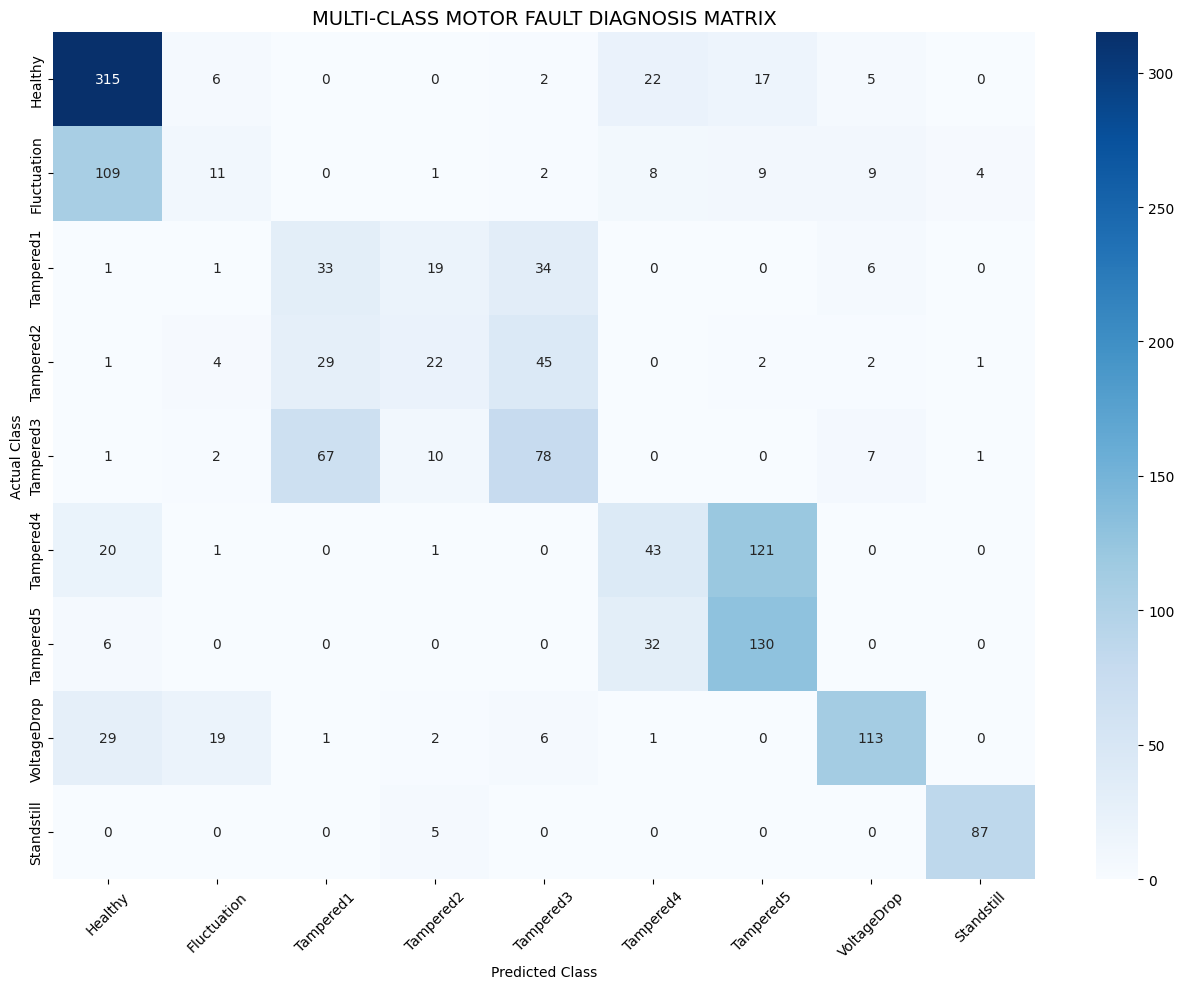

In [6]:
# =====================================================================
# SUPERVISED GCDAE MOTOR FAULT DIAGNOSIS SYSTEM 
# =====================================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split

# =====================================================================
# 1. DATASET
# =====================================================================

class MotorDataset(Dataset):
    def __init__(self, file_dict, label_map, target_shape=(64, 64), baseline_mean=None, baseline_std=None):
        self.data = []
        self.labels = []
        self.target_shape = target_shape
        row_size = target_shape[0] * target_shape[1]

        all_raw_data = []
        temp_file_data = {}

        for case_name, path in file_dict.items():
            if not os.path.exists(path):
                print(f"Missing file: {path}")
                continue
            
            raw_list = []
            try:
                with open(path, 'r', encoding='utf-8', errors='ignore') as f:
                    for line in f:
                        cleaned_line = line.replace('\t', ',').replace(' ', ',').replace(';', ',')
                        parts = cleaned_line.strip().split(',')
                        for part in parts:
                            if not part:
                                continue
                            try:
                                raw_list.append(float(part))
                            except ValueError:
                                continue
                
                if raw_list:
                    temp_file_data[case_name] = np.array(raw_list, dtype=np.float32)
                    all_raw_data.extend(raw_list)
                    
            except Exception as e:
                print(f"Error parsing {path}: {e}")

        if not all_raw_data:
            raise ValueError("No valid data could be loaded from any of the provided files.")

        # Global Standardization Setup
        if baseline_mean is not None and baseline_std is not None:
            self.mean = baseline_mean
            self.std = baseline_std
        else:
            all_raw_numpy = np.array(all_raw_data, dtype=np.float32)
            self.mean = all_raw_numpy.mean()
            self.std = all_raw_numpy.std()
            if self.std < 1e-6:
                self.std = 1.0

        for case_name, raw_numpy in temp_file_data.items():
            normalized = (raw_numpy - self.mean) / self.std
            num_samples = len(normalized) // row_size
            
            if num_samples == 0:
                continue
                
            normalized = normalized[:num_samples * row_size]
            reshaped_frames = normalized.reshape(num_samples, 1, target_shape[0], target_shape[1])
            
            self.data.append(reshaped_frames)
            target_label = label_map[case_name]
            self.labels.extend([target_label] * num_samples)
            print(f"Loaded {num_samples} frames for category: {case_name} (Label {target_label})")

        self.data = np.vstack(self.data)
        self.labels = np.array(self.labels, dtype=np.int64)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.data[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

# =====================================================================
# 2. FILE & LABEL MAPS
# =====================================================================

all_motor_files = {
    "baseline": "baseline_motor_data.csv",
    "reassembled": "motor_running_naked_screw_positioned_again.csv",
    "fluctuations": "motor_running_naked_and_electrical_flactuations.csv",
    "tampered_1": "motor_running_naked_screw_fell_four.csv",
    "tampered_2": "motor_running_naked_screw_fell_three.csv",
    "tampered_3": "motor_running_naked_and_loose_a_bit.csv",
    "tampered_4": "motor_running_wheel_added.csv",
    "tampered_5": "motor_running_wheel_loosen_bit.csv",
    "voltage_drop": "motor_running_naked_and_voltage_drop_by_one.csv",
    "standstill": "no_motor_running.csv"
}

label_map = {
    "baseline": 0, "reassembled": 0,
    "fluctuations": 1,
    "tampered_1": 2,
    "tampered_2": 3,
    "tampered_3": 4,
    "tampered_4": 5,
    "tampered_5": 6,
    "voltage_drop": 7,
    "standstill": 8
}

class_names = [
    "Healthy", "Fluctuation", "Tampered1", "Tampered2", 
    "Tampered3", "Tampered4", "Tampered5", "VoltageDrop", "Standstill"
]

# =====================================================================
# 3. SPLIT DATA UNIFORMLY
# =====================================================================

print("\nInitializing dataset...")
full_dataset = MotorDataset(all_motor_files, label_map, target_shape=(64, 64))

X_raw = full_dataset.data
y_raw = full_dataset.labels

X_train_raw, X_val_raw, y_train_labels, y_val_labels = train_test_split(
    X_raw, y_raw, test_size=0.25, random_state=42, stratify=y_raw
)

class SubDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)

# Add class weights calculation to tackle data sample imbalance directly
class_counts = np.bincount(y_train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(
    torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

train_loader = DataLoader(SubDataset(X_train_raw, y_train_labels), batch_size=32, shuffle=True)
val_loader = DataLoader(SubDataset(X_val_raw, y_val_labels), batch_size=32, shuffle=False)

# =====================================================================
# 4. SUPERVISED GCDAE CLASSIFIER MODEL
# =====================================================================

class GCDAEClassifier(nn.Module):
    def __init__(self, num_classes=9):
        super(GCDAEClassifier, self).__init__()
        
        # Original GCDAE Encoder backbone architecture maintained
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1),
            nn.BatchNorm2d(16), # Added batchnorm for stability
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        self.fc_enc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 32),
            nn.ReLU()
        )
        
        # New classification head replacing the reconstruction decoder completely
        self.classifier = nn.Sequential(
            nn.Dropout(0.4), # Added regularization to stop feature collapse
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        features = self.encoder(x)
        latent_z = self.fc_enc(features)
        out = self.classifier(latent_z)
        return out, latent_z

# =====================================================================
# 5. TRAINING LOOP
# =====================================================================

def train_classifier(model, loader, criterion, optimizer, device, epochs=30):
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            
            outputs, _ = model(x)
            loss = criterion(outputs, y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
            
        avg_loss = total_loss / len(loader)
        acc = 100. * correct / total
        print(f"Epoch {epoch+1:02d} | Cross-Entropy Loss: {avg_loss:.4f} | Train Acc: {acc:.2f}%")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GCDAEClassifier(num_classes=9)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print("\nTraining Supervised GCDAE Classifier...")
train_classifier(model, train_loader, criterion, optimizer, device, epochs=35)

# =====================================================================
# 6. EVALUATION
# =====================================================================

def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_latent = []
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs, latent_z = model(x)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y.numpy())
            all_latent.append(latent_z.cpu().numpy())
            
    return np.array(all_preds), np.array(all_labels), np.vstack(all_latent)

print("\nEvaluating model on validation slice...")
y_pred, y_test, X_test_latent = evaluate_model(model, val_loader, device)

accuracy = accuracy_score(y_test, y_pred)
print("\n====================================")
print(f"Classification Accuracy: {accuracy:.4f}")
print("====================================\n")

print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# =====================================================================
# 7. CONFUSION MATRIX PLOT
# =====================================================================

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(13, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("MULTI-CLASS MOTOR FAULT DIAGNOSIS MATRIX", fontsize=14)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Initializing dataset...
Loaded 735 frames for category: baseline (Label 0)
Loaded 733 frames for category: reassembled (Label 0)
Loaded 612 frames for category: fluctuations (Label 1)
Loaded 376 frames for category: tampered_1 (Label 2)
Loaded 423 frames for category: tampered_2 (Label 3)
Loaded 665 frames for category: tampered_3 (Label 4)
Loaded 746 frames for category: tampered_4 (Label 5)
Loaded 670 frames for category: tampered_5 (Label 6)
Loaded 685 frames for category: voltage_drop (Label 7)
Loaded 367 frames for category: standstill (Label 8)

Training System...
Epoch 01 | Joint Loss: 2.6037 | Train Acc: 13.95%
Epoch 02 | Joint Loss: 2.3518 | Train Acc: 17.48%
Epoch 03 | Joint Loss: 2.2617 | Train Acc: 21.00%
Epoch 04 | Joint Loss: 2.2129 | Train Acc: 25.33%
Epoch 05 | Joint Loss: 2.1273 | Train Acc: 29.43%
Epoch 06 | Joint Loss: 2.0555 | Train Acc: 30.01%
Epoch 07 | Joint Loss: 2.0518 | Train Acc: 33.24%
Epoch 08 | Joint Loss: 2.0419 | Train Acc: 32.78%
Epoch 09 | Joint Loss:

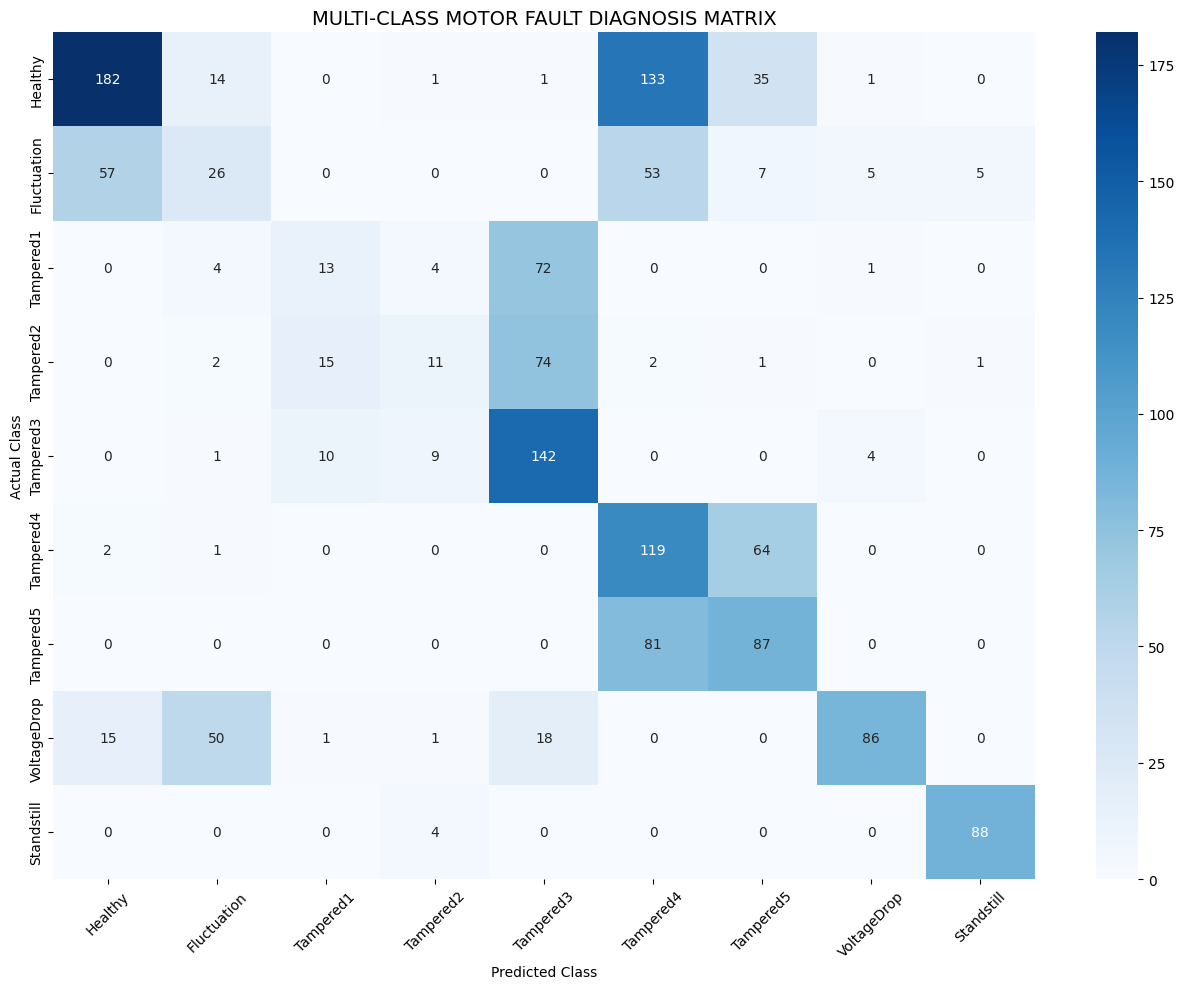


Running t-SNE latent space layout computation...


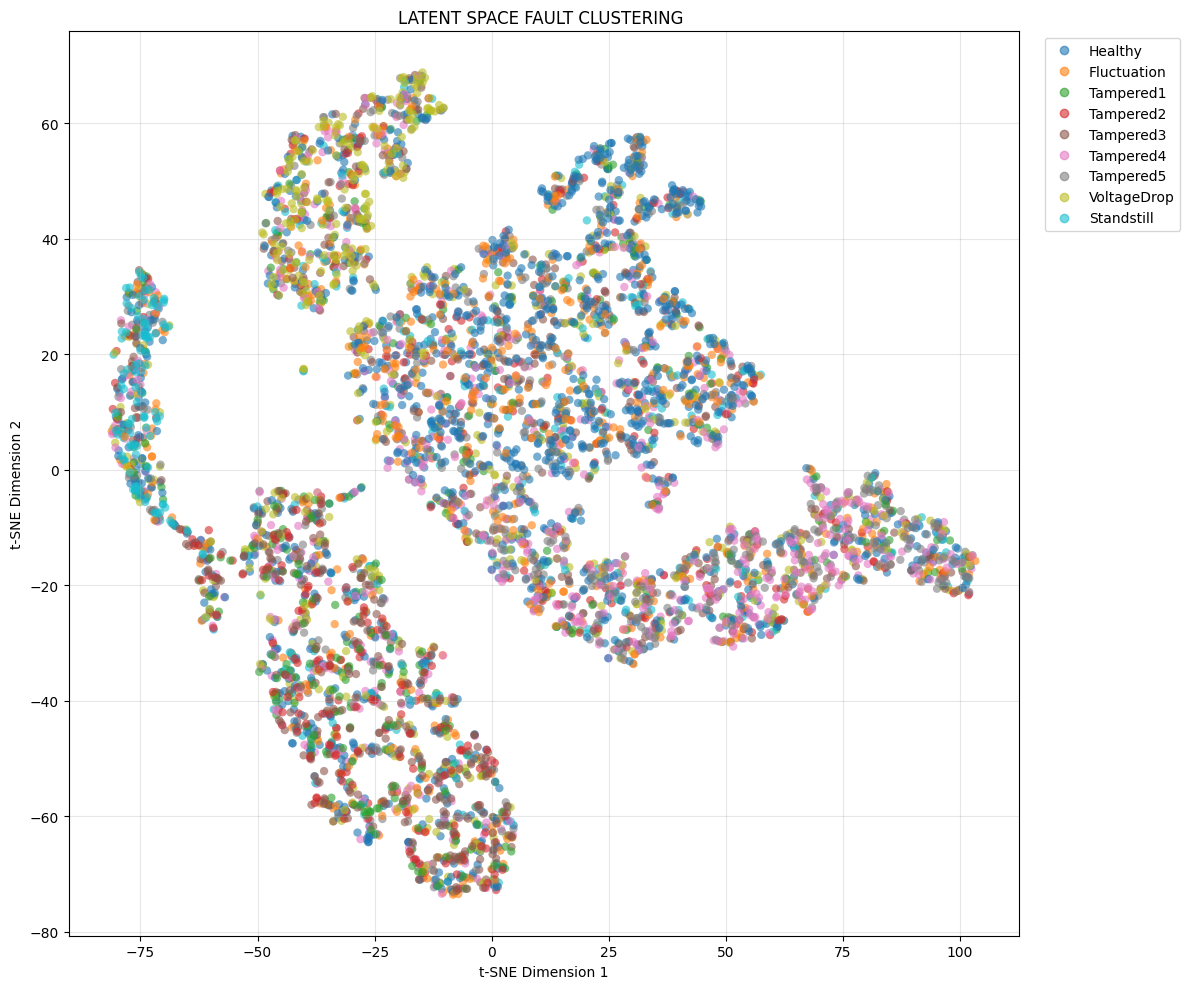


Generating reconstruction spatial checks...


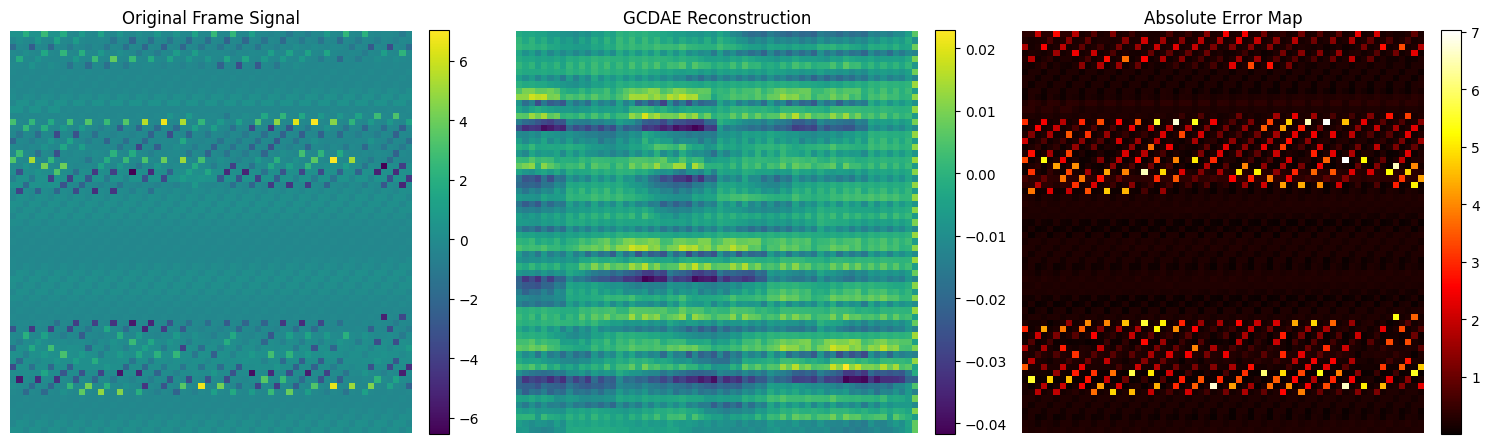

In [4]:
# =====================================================================
# SUPERVISED GCDAE MOTOR FAULT DIAGNOSIS SYSTEM (FULL RESTORED)
# =====================================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

# =====================================================================
# 1. DATASET
# =====================================================================

class MotorDataset(Dataset):
    def __init__(self, file_dict, label_map, target_shape=(64, 64), baseline_mean=None, baseline_std=None):
        self.data = []
        self.labels = []
        self.target_shape = target_shape
        row_size = target_shape[0] * target_shape[1]

        all_raw_data = []
        temp_file_data = {}

        for case_name, path in file_dict.items():
            if not os.path.exists(path):
                print(f"Missing file: {path}")
                continue
            
            raw_list = []
            try:
                with open(path, 'r', encoding='utf-8', errors='ignore') as f:
                    for line in f:
                        cleaned_line = line.replace('\t', ',').replace(' ', ',').replace(';', ',')
                        parts = cleaned_line.strip().split(',')
                        for part in parts:
                            if not part:
                                continue
                            try:
                                raw_list.append(float(part))
                            except ValueError:
                                continue
                
                if raw_list:
                    temp_file_data[case_name] = np.array(raw_list, dtype=np.float32)
                    all_raw_data.extend(raw_list)
                    
            except Exception as e:
                print(f"Error parsing {path}: {e}")

        if not all_raw_data:
            raise ValueError("No valid data could be loaded from any of the provided files.")

        # Global Standardization
        if baseline_mean is not None and baseline_std is not None:
            self.mean = baseline_mean
            self.std = baseline_std
        else:
            all_raw_numpy = np.array(all_raw_data, dtype=np.float32)
            self.mean = all_raw_numpy.mean()
            self.std = all_raw_numpy.std()
            if self.std < 1e-6:
                self.std = 1.0

        for case_name, raw_numpy in temp_file_data.items():
            normalized = (raw_numpy - self.mean) / self.std
            num_samples = len(normalized) // row_size
            
            if num_samples == 0:
                continue
                
            normalized = normalized[:num_samples * row_size]
            reshaped_frames = normalized.reshape(num_samples, 1, target_shape[0], target_shape[1])
            
            self.data.append(reshaped_frames)
            target_label = label_map[case_name]
            self.labels.extend([target_label] * num_samples)
            print(f"Loaded {num_samples} frames for category: {case_name} (Label {target_label})")

        self.data = np.vstack(self.data)
        self.labels = np.array(self.labels, dtype=np.int64)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.data[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

# =====================================================================
# 2. FILE & LABEL MAPS
# =====================================================================

all_motor_files = {
    "baseline": "baseline_motor_data.csv",
    "reassembled": "motor_running_naked_screw_positioned_again.csv",
    "fluctuations": "motor_running_naked_and_electrical_flactuations.csv",
    "tampered_1": "motor_running_naked_screw_fell_four.csv",
    "tampered_2": "motor_running_naked_screw_fell_three.csv",
    "tampered_3": "motor_running_naked_and_loose_a_bit.csv",
    "tampered_4": "motor_running_wheel_added.csv",
    "tampered_5": "motor_running_wheel_loosen_bit.csv",
    "voltage_drop": "motor_running_naked_and_voltage_drop_by_one.csv",
    "standstill": "no_motor_running.csv"
}

label_map = {
    "baseline": 0, "reassembled": 0,
    "fluctuations": 1,
    "tampered_1": 2,
    "tampered_2": 3,
    "tampered_3": 4,
    "tampered_4": 5,
    "tampered_5": 6,
    "voltage_drop": 7,
    "standstill": 8
}

class_names = [
    "Healthy", "Fluctuation", "Tampered1", "Tampered2", 
    "Tampered3", "Tampered4", "Tampered5", "VoltageDrop", "Standstill"
]

# =====================================================================
# 3. SPLIT DATA UNIFORMLY
# =====================================================================

print("\nInitializing dataset...")
full_dataset = MotorDataset(all_motor_files, label_map, target_shape=(64, 64))

X_raw = full_dataset.data
y_raw = full_dataset.labels

X_train_raw, X_val_raw, y_train_labels, y_val_labels = train_test_split(
    X_raw, y_raw, test_size=0.25, random_state=42, stratify=y_raw
)

class SubDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)

class_counts = np.bincount(y_train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(
    torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

train_loader = DataLoader(SubDataset(X_train_raw, y_train_labels), batch_size=32, shuffle=True)
val_loader = DataLoader(SubDataset(X_val_raw, y_val_labels), batch_size=32, shuffle=False)

# =====================================================================
# 4. SUPERVISED GCDAE CLASSIFIER MODEL + DECODER RESTORED
# =====================================================================

class GCDAEClassifier(nn.Module):
    def __init__(self, num_classes=9):
        super(GCDAEClassifier, self).__init__()
        
        # Encoder backbone
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1),
            nn.BatchNorm2d(16), 
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        self.fc_enc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 32),
            nn.ReLU()
        )
        
        # Classification Head
        self.classifier = nn.Sequential(
            nn.Dropout(0.4), 
            nn.Linear(32, num_classes)
        )
        
        # Decoder Head (Used strictly to retain reconstruction heatmap capability)
        self.fc_dec = nn.Sequential(
            nn.Linear(32, 64 * 8 * 8),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, 2, 1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, 2, 1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, 2, 1, output_padding=1)
        )

    def forward(self, x):
        features = self.encoder(x)
        latent_z = self.fc_enc(features)
        class_out = self.classifier(latent_z)
        
        # Reconstruct structural layout
        dec_feat = self.fc_dec(latent_z)
        dec_feat = dec_feat.view(dec_feat.size(0), 64, 8, 8)
        recon_out = self.decoder(dec_feat)
        
        return class_out, latent_z, recon_out

# =====================================================================
# 5. TRAINING LOOP (JOINT LEARNING: CLASSIFICATION + RECONSTRUCTION)
# =====================================================================

def train_system(model, loader, criterion_cls, optimizer, device, epochs=35):
    model.to(device)
    criterion_mse = nn.MSELoss() # Secondary loss to keep the autoencoder spatial structures sharp
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            
            outputs_cls, _, outputs_recon = model(x)
            
            # Combine targets (Optimize diagnostic boundaries while keeping structural representations)
            loss_cls = criterion_cls(outputs_cls, y)
            loss_mse = criterion_mse(outputs_recon, x)
            loss = loss_cls + 0.5 * loss_mse
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = outputs_cls.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
            
        avg_loss = total_loss / len(loader)
        acc = 100. * correct / total
        print(f"Epoch {epoch+1:02d} | Joint Loss: {avg_loss:.4f} | Train Acc: {acc:.2f}%")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GCDAEClassifier(num_classes=9)

criterion_cls = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print("\nTraining System...")
train_system(model, train_loader, criterion_cls, optimizer, device, epochs=35)

# =====================================================================
# 6. EVALUATION & EXTRACTION
# =====================================================================

def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_latent = []
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs, latent_z, _ = model(x)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y.numpy())
            all_latent.append(latent_z.cpu().numpy())
            
    return np.array(all_preds), np.array(all_labels), np.vstack(all_latent)

print("\nEvaluating model representations...")
y_pred, y_test, X_test_latent = evaluate_model(model, val_loader, device)

# Extract train latents to visualize total clusters via t-SNE
_, _, X_train_latent = evaluate_model(model, train_loader, device)

accuracy = accuracy_score(y_test, y_pred)
print("\n====================================")
print(f"Classification Accuracy: {accuracy:.4f}")
print("====================================\n")

print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# =====================================================================
# 7. CONFUSION MATRIX PLOT
# =====================================================================

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(13, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("MULTI-CLASS MOTOR FAULT DIAGNOSIS MATRIX", fontsize=14)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =====================================================================
# 8. RESTORED: LATENT SPACE VISUALIZATION (t-SNE)
# =====================================================================

print("\nRunning t-SNE latent space layout computation...")
X_all_latent = np.vstack([X_train_latent, X_test_latent])
y_all_latent = np.concatenate([y_train_labels, y_test])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_all_latent)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_all_latent, cmap='tab10', alpha=0.6, edgecolors='none')
plt.legend(handles=scatter.legend_elements()[0], labels=class_names, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title("LATENT SPACE FAULT CLUSTERING ")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================================
# 9. RESTORED: RECONSTRUCTION ERROR HEATMAP
# =====================================================================

print("\nGenerating reconstruction spatial checks...")

sample_batch, _ = next(iter(val_loader))
sample = sample_batch[0:1].to(device)

model.eval()
with torch.no_grad():
    _, _, recon = model(sample)

error_map = torch.abs(recon - sample)

sample_np = sample[0, 0].cpu().numpy()
recon_np = recon[0, 0].cpu().numpy()
error_np = error_map[0, 0].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(sample_np, cmap='viridis')
axes[0].set_title("Original Frame Signal")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(recon_np, cmap='viridis')
axes[1].set_title("GCDAE Reconstruction")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(error_np, cmap='hot')
axes[2].set_title("Absolute Error Map")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()